In [1]:
import xarray as xr
import json

import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import dpa_ensemble as de
import utils as ut
import evaluation
import pandas as pd
import torch
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

data_version = "v5"

In [2]:
# Factual
# load true test data
settings_file_path = f"/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/{data_version}_dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)
    
### Load temperature data ###
ds_test_eth_fact = xr.open_dataset(settings['dataset_trefht_eth_transient'])
ds_test_eth_fact

# load DPA ensemble

# v5 
# factual
dpa_eth_fact = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue/06022026_reference_period_1950-1980_v5_dpa_train_settings.json/dpa_ensemble_after_20_epochs/eth_ensemble_after_20_epochs/ETH_gen_dpa_ens_20_dataset_restored.nc")
# counterfactual
dpa_eth_cf = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue/06022026_reference_period_1950-1980_v5_dpa_train_settings.json/dpa_ensemble_after_20_epochs/eth_ensemble_after_20_epochs/ETH_cf_gen_dpa_ens_20_dataset_restored.nc")


# v4
#dpa_eth_fact = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v4_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_bs128_bnisTrue/dpa_ensemble_after_20_epochs/eth_ensemble_after_20_epochs/ETH_gen_dpa_ens_20_dataset_restored.nc")

In [3]:
# Counterfactual
# load true test data
settings_file_path = f"/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/{data_version}_dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)
    
### Load temperature data ###
ds_test_eth_cf = xr.open_dataset(settings['dataset_trefht_eth_nudged_shifted'])
ds_test_eth_cf

# load DPA ensemble
dpa_eth_cf

<xarray.Dataset> Size: 6GB
Dimensions:          (ensemble_member: 100, time: 14307, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 6GB ...

In [ ]:
# compute domain average temperature
#dpa_eth_ens_spatial_mean = dpa_eth_fact.TREFHT.mean(dim=("lat","lon"))
#dpa_eth_ens_spatial_mean_cf = dpa_eth_cf.TREFHT.mean(dim=("lat","lon"))

# DAE ensemble mean
#fact_dpa_mean = dpa_eth_fact.TREFHT.mean(dim="ensemble_member") # factual
#fact_dpa_mean = dpa_eth_fact.TREFHT.median(dim="ensemble_member") # factual
#cf_dpa_mean = dpa_eth_cf.TREFHT.mean(dim="ensemble_member") # counterfactual

## Min/Max temperature time series

In [4]:
####################
### Load my data ###
####################
# load my data
settings_file_path = f"/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/{data_version}_dpa_train_settings.json"

with open(settings_file_path, 'r') as file:
        settings = json.load(file)

print("Top-level keys:", list(settings.keys()))



# Load ETH ensemble data
# Test data
trefht_eth = xr.open_dataset(settings['dataset_trefht_eth_transient'])
print(trefht_eth)

#z500_eth = xr.open_dataset(settings['dataset_z500_eth_test'])
#print(z500_eth)


### Germany ###
    
# coordinates 
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

# cut train data
#trefht_le_ger = trefht_le.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
#print(trefht_le_ger)

# cut test data
trefht_eth_ger = trefht_eth.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
print(trefht_eth_ger)

# calculate weighted means
#weights
weights_ger_pre = np.cos(np.deg2rad(trefht_eth_ger["lat"]))
weights_ger = weights_ger_pre / weights_ger_pre.sum()

# training data
#trefht_le_ger_mean = trefht_le_ger.TREFHT.weighted(weights_ger).mean(dim=("lat", "lon"))
#trefht_le_ger_mean

# test_data
trefht_eth_ger_mean = trefht_eth_ger.TREFHT.weighted(weights_ger).mean(dim=("lat", "lon"))
trefht_eth_ger_mean




Top-level keys: ['output_dir', 'dataset_trefht', 'dataset_z500', 'dataset_trefht_eth_transient', 'dataset_trefht_eth_nudged_shifted', 'dataset_z500_eth_test']
<xarray.Dataset> Size: 59MB
Dimensions:  (lat: 32, lon: 32, time: 14307)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 59MB ...
<xarray.Dataset> Size: 3MB
Dimensions:  (lat: 6, lon: 8, time: 14307)
Coordinates:
  * lon      (lon) float64 64B 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * lat      (lat) float64 48B 48.53 49.48 50.42 51.36 52.3 53.25
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 3MB ...


<xarray.DataArray 'TREFHT' (time: 14307)> Size: 114kB
array([-4.49337157, -1.31087361,  1.37090888, ...,  6.5623436 ,
        4.95777001,  3.47292763], shape=(14307,))
Coordinates:
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00

[   3   22   42   58   87  103  131  136  154  187  195  221  242  249
  268  292  317  323  359  373  388  404  435  439  458  478  497  530
  540  556  572  591  610  641  648  667  692  716  739  745  763  789
  803  819  837  866  877  897  916  934  952  971  998 1009 1038 1052
 1082 1093 1116 1137 1152 1173 1180 1209 1225 1239 1270 1276 1305 1316
 1333 1351 1372 1389 1412 1443 1462 1479 1499 1503 1537 1541 1571 1589
 1596 1618 1647 1664 1674 1695 1712 1733 1753 1778 1793 1814 1827 1859
 1866 1883 1905 1923 1945 1957 1976 2001 2017 2037 2067 2072 2107 2118
 2136 2150 2166 2185 2218 2232 2257 2271 2285 2300 2333 2344 2357 2377
 2400 2422 2432 2458 2470 2504 2515 2544 2564 2579 2601 2618 2629 2651
 2664 2688 2701 2722 2742 2766 2778 2803 2812 2838 2867 2880 2889 2925
 2943 2960 2981 2996 3020 3030 3052 3070 3087 3107 3126 3144 3163 3175
 3194 3222 3232 3265 3284 3299 3312 3342 3347 3365 3394 3403 3432 3441
 3474 3477 3510 3524 3539 3553 3583 3593 3621 3642 3659 3669 3691 3716
 3739 

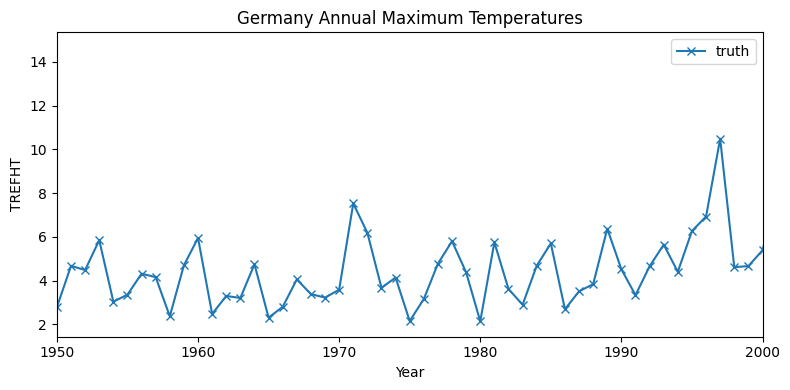

In [5]:
trefht_eth_ger_mean_1300 = trefht_eth_ger_mean.isel(time=slice(0,4769))
da_max_year_pre = trefht_eth_ger_mean_1300.groupby("time.year").max()

s = trefht_eth_ger_mean_1300.to_series()                      # pandas Series with DatetimeIndex
t_max = s.groupby(s.index.year).idxmax()

da_max_year = da_max_year_pre.assign_coords(year=(t_max.values))
da_max_year

# integer indices in the original time axis
time_index = pd.Index(trefht_eth_ger_mean_1300.time.values)
idx = time_index.get_indexer(t_max.values)
print(idx)
plt.figure(figsize=(8, 4))

plt.plot(
    da_max_year_pre.year.values,
    da_max_year.values,
    marker='x',
    label = "truth"
)

plt.xlabel("Year")
plt.ylabel(trefht_eth_ger_mean.name if trefht_eth_ger_mean.name is not None else "Value")
plt.title("Germany Annual Maximum Temperatures")

plt.xlim(1950, 2000)
plt.legend()
plt.tight_layout()

#plt.savefig("figures/vrfdynanical_adjustment_ts.pdf")
plt.show()

In [27]:
### DPA Ensemble ###
# standard deviation, germany mean
dpa_ens_std = dpa_eth_fact.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max)).std(dim="ensemble_member") # before: dpa_ensemble_restored.TREFHT
dpa_ens_std_ger = dpa_ens_std.weighted(weights_ger).mean(dim=('lat', 'lon')).isel(time=slice(0,4769))

# germany mean of ensemble mean
#dpa_ens_mean_ger_mean = fact_dpa_mean.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max)).weighted(weights_ger).mean(dim=('lat', 'lon')).isel(time=slice(0,4769)) # before: dpa_ensemble_restored
#print(dpa_ens_mean_ger_mean.shape)
#dpa_ens_mean_ger_cf = dpa_ens_mean_cf_1300_restored.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# dpa ensemble of germany average (ensemble_member, )
dpa_ens_ger_1300 = dpa_eth_fact.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max)).weighted(weights_ger).mean(dim=('lat', 'lon')).isel(time=slice(0,4769))
dpa_ens_ger_1300

dpa_ens_mean_ger_mean = dpa_ens_ger_1300.median(dim="ensemble_member")
dpa_ens_mean_ger_mean

<xarray.Dataset> Size: 76kB
Dimensions:  (time: 4769)
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (time) float64 38kB -5.157 -1.232 -0.3661 ... 8.869 3.563 5.609

In [45]:

dpa_quantiles = dpa_ens_ger_1300.TREFHT.quantile([0.01, 0.99], dim="ensemble_member")
dpa_quantiles


<xarray.DataArray 'TREFHT' (quantile: 2, time: 4769)> Size: 76kB
array([[-7.23286722, -2.8181402 , -2.00906024, ...,  6.29978217,
         0.97299133,  2.88977211],
       [-3.13807381,  0.54623577,  1.94628036, ..., 11.31094711,
         5.70065324,  8.39949571]], shape=(2, 4769))
Coordinates:
  * time      (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
  * quantile  (quantile) float64 16B 0.01 0.99

## Add quantile regression model

In [55]:
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/data_exploration')

import utils as ut
import pytorch_quantile_regression as pqr
import torch

# show quantile regression model 
# ---- Load metadata ----
# v5 model
model_path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/baseline_quantile_regression/v5_data_quantile_regression_ger_gradient_descent_2026-02-09_11-52/"

# v4 model
#model_path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/baseline_quantile_regression/v4_data_quantile_regression_ger_gradient_descent_2025-12-08_14-39/"

with open(f"{model_path}metadata.json", "r") as f:
    meta = json.load(f)

quantiles = meta["quantiles"]
n_features = meta["n_features"]
n_quantiles = len(quantiles)

# ---- Load checkpoint ----
#ckpt_path = meta["last_checkpoint"] # v4 model
ckpt_path = f"{model_path}checkpoint_epoch_200.pth" # v5 model
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

# ---- Rebuild model ----
model = pqr.LinearMultiQuantileRegressor(
    n_features=n_features,
    n_quantiles=n_quantiles
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# ---- Move to GPU (optional) ----
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

In [56]:
# ---- Prepare test data ----
# load my data
settings_file_path = f"../joint_training/{data_version}_dpa_train_settings.json" #used v2 here for a long time

with open(settings_file_path, 'r') as file:
        settings = json.load(file)

# Load Z500 data
z500_train = xr.open_dataset(settings['dataset_z500']).pseudo_pcs.isel(time=slice(0,90*4769))
z500_train_np, mean_train, std_train = ut.standardize_numpy(z500_train.values)


z500_test = xr.open_dataset(settings['dataset_z500_eth_test']).pseudo_pcs
z500_test_np, _, _ = ut.standardize_numpy(z500_test.values, mean_train, std_train)

X_test_torch = torch.from_numpy(z500_test_np.astype("float32")).to(device)
print(X_test_torch.shape)


# ---- Predict from Qu. regression model ----
with torch.no_grad():
    preds = model(X_test_torch)   # shape (N_test, n_quantiles)
quantile_predictions = preds.cpu().numpy()

torch.Size([14307, 1001])


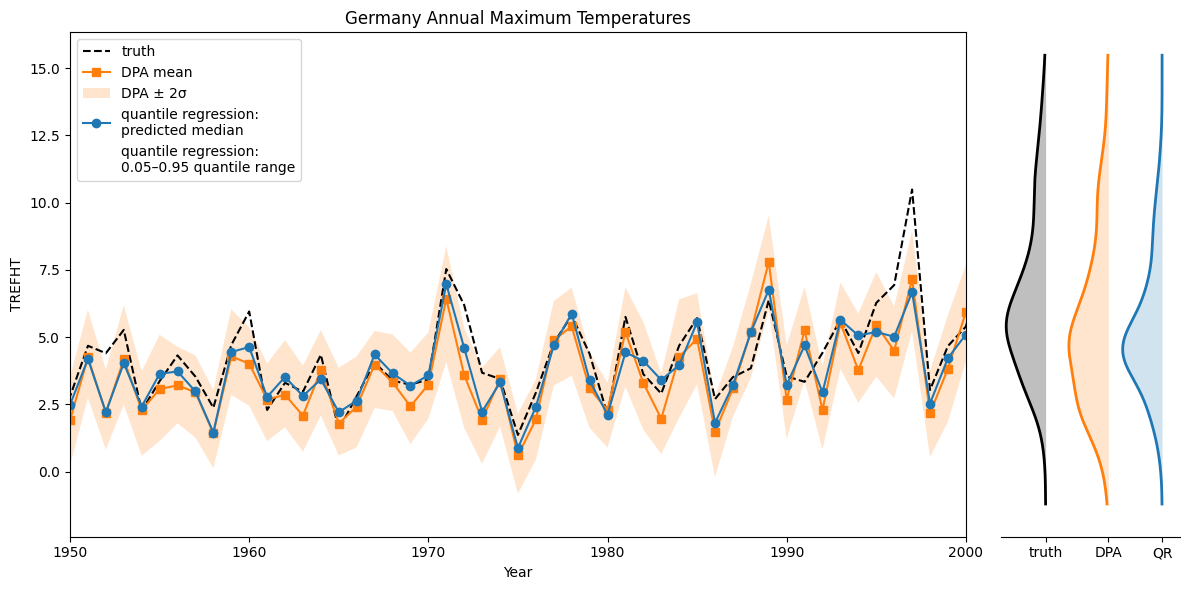

In [57]:
# Time series + right-side KDE-only marginal densities (no hist)
# KDE curves are side-by-side (three columns), with bumps to the LEFT
# and shaded area under each density.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable


# ============================================================
# Helper: plot LEFT-pointing KDE in a fixed horizontal "column"
# ============================================================

def kde_column_left(ax, values, y_grid, x_center, width=0.22,
                    color="k", lw=2, alpha_fill=0.25, bw_method=None):
    """
    Plot a vertical KDE curve (density vs y) into a fixed column on ax,
    with the density extending to the LEFT of the column center and
    shaded under the curve.

    Mapping:
      dens_norm in [0,1]
      x = x_center - dens_norm * width   (so bumps go left)
      baseline = x_center

    Parameters
    ----------
    ax : matplotlib axis
    values : array-like
    y_grid : array-like
    x_center : float (0..1)
    width : float
    color : str
    lw : float
    alpha_fill : float
    bw_method : optional gaussian_kde bw_method
    """
    v = np.asarray(values).ravel()
    v = v[np.isfinite(v)]
    if v.size < 2:
        return

    kde = gaussian_kde(v, bw_method=bw_method)
    dens = kde(y_grid)

    dmax = np.nanmax(dens)
    if not np.isfinite(dmax) or dmax <= 0:
        return

    dens_norm = dens / dmax

    x_curve = x_center - dens_norm * width
    x_base = np.full_like(y_grid, x_center)

    # Shade under curve (between baseline and curve)
    ax.fill_betweenx(
        y_grid,
        x_curve,
        x_base,
        color=color,
        alpha=alpha_fill,
        linewidth=0
    )

    # Outline curve
    ax.plot(x_curve, y_grid, color=color, lw=lw)


# ============================================================
# Figure
# ============================================================
idx_abs = np.load("yearly_absolute_max_indices_ger.npy")
fig, ax = plt.subplots(figsize=(12, 6))

# --- main time series ---

# truth
ax.plot(
    da_max_year_pre.year.values,
    trefht_eth_ger_mean_1300.values[idx_abs],
    label="truth",
    color="black",
    linestyle="--"
    
)


# DPA ensemble mean
ax.plot(
    da_max_year_pre.year.values,
    dpa_ens_mean_ger_mean.TREFHT.isel(time=idx_abs).values,
    marker="s",
    color="tab:orange",
    label="DPA mean"
)

# plot single dpa members
#for i in range(100):
#    ax.plot(da_max_year_pre.year.values,
#            dpa_ens_ger_1300.TREFHT.values[i, idx_abs], color = "tab:orange", linewidth=0.2)

# --- envelopes ---
#n_stds = 2 #1.645
# standard deviations
#upper_env_dpa = dpa_ens_mean_ger_mean.TREFHT + n_stds * dpa_ens_std_ger.TREFHT
#lower_env_dpa = dpa_ens_mean_ger_mean.TREFHT - n_stds * dpa_ens_std_ger.TREFHT

quantile_lower = 0.05
quantile_upper = 0.95
dpa_quantiles = dpa_ens_ger_1300.TREFHT.quantile([quantile_lower, quantile_upper], dim="ensemble_member")
upper_env_dpa = dpa_quantiles.sel(quantile=quantile_lower)
lower_env_dpa = dpa_quantiles.sel(quantile=quantile_upper)

ax.fill_between(
    da_max_year_pre.year.values,
    lower_env_dpa.isel(time=idx_abs).values,
    upper_env_dpa.isel(time=idx_abs).values,
    alpha=0.2,
    label=f"DPA ± {n_stds}σ",
    color="tab:orange",
    edgecolor="none"
)


# quantile regression median
ax.plot(
    da_max_year_pre.year.values,
    quantile_predictions[0:4769, 9][idx_abs],
    color="tab:blue",
    marker="o",
    label="quantile regression:\npredicted median"
)

# quantile interval (0.05–0.95)
lower_env = quantile_predictions[0:4769, 0][idx_abs]
upper_env = quantile_predictions[0:4769, 18][idx_abs]

ax.fill_between(
    da_max_year_pre.year.values,
    lower_env,
    upper_env,
    color="none", #"tab:blue",
    alpha=0.2,
    edgecolor="none",
    label="quantile regression:\n0.05–0.95 quantile range"
)

# --- main axis formatting ---
ax.set_xlabel("Year")
ax.set_ylabel(trefht_eth_ger_mean_1300.name or "Value")
ax.set_title("Germany Annual Maximum Temperatures")
ax.legend(loc="upper left")
ax.set_xlim(1950, 2000)

# ============================================================
# Right marginal axis (KDE-only, left-pointing, shaded)
# ============================================================

divider = make_axes_locatable(ax)
ax_dist = divider.append_axes(
    "right",
    size="20%",
    pad=0.35,
    sharey=ax
)

# --- data for marginal KDEs ---
truth_vals = trefht_eth_ger_mean_1300.values[idx_abs]
model_vals = quantile_predictions[0:4769, 9][idx_abs]
dpa_vals = dpa_ens_ger_1300.TREFHT.values[0, idx_abs].ravel()  # your current choice

# y-grid for KDE evaluation (cover all distributions)
y_min = np.nanmin([np.nanmin(truth_vals), np.nanmin(model_vals), np.nanmin(dpa_vals)])
y_max = np.nanmax([np.nanmax(truth_vals), np.nanmax(model_vals), np.nanmax(dpa_vals)])
y_pad = 0.05 * (y_max - y_min) if (y_max > y_min) else 1.0
y_grid = np.linspace(y_min - y_pad, y_max + y_pad, 400)

# Clear and plot KDE columns (separate x-centers, no overlap)
ax_dist.cla()

# Columns: truth | DPA | QR
kde_column_left(ax_dist, truth_vals, y_grid, x_center=0.25, width=0.22,
                color="black", lw=2, alpha_fill=0.25)
kde_column_left(ax_dist, dpa_vals,   y_grid, x_center=0.60, width=0.22,
                color="tab:orange", lw=2, alpha_fill=0.20)
kde_column_left(ax_dist, model_vals, y_grid, x_center=0.90, width=0.22,
                color="tab:blue", lw=2, alpha_fill=0.20)

# Styling
ax_dist.set_xlim(0, 1)
ax_dist.set_xticks([0.25, 0.60, 0.90])
ax_dist.set_xticklabels(["truth", "DPA", "QR"])

ax_dist.yaxis.set_visible(False)
ax_dist.spines["top"].set_visible(False)
ax_dist.spines["right"].set_visible(False)
ax_dist.spines["left"].set_visible(False)

# ============================================================
# Final layout
# ============================================================

plt.tight_layout()
#plt.ylim(-2, 10)
#plt.savefig("figures/fig02.pdf")
plt.show()




In [36]:
print(np.mean(truth_vals))
print(np.mean(dpa_vals))
print(np.mean(model_vals))



6.44668596545348
5.272841209694056
7.184671


In [32]:
print(np.median(truth_vals))
print(np.median(dpa_vals))
print(np.median(model_vals))

5.804969832773572
4.728522714397168
4.882385


In [25]:
truth_vals.shape

(251,)

In [34]:
corr_dpa = np.corrcoef(truth_vals, dpa_ens_mean_ger_mean.TREFHT.isel(time=idx_abs).values)[0, 1]
print(corr_dpa)
corr_qr = np.corrcoef(truth_vals, model_vals)[0, 1]
print(corr_qr)

0.9282849708148985
0.9234752752366108
